In [2]:
import pandas as pd

customers = pd.read_csv("data/kyc_customers.csv")
watchlist = pd.read_csv("data/watchlist.csv")

customers.head()

,customer_id,full_name,date_of_birth,nationality,country_of_residence,occupation,source_of_funds,product_type,onboarding_channel,onboarding_date,id_type,id_verified,is_pep,adverse_media_flag,annual_income,expected_monthly_activity,actual_monthly_activity
0,100001,Dmitri Okafor,1989-01-06,Nigeria,Nigeria,Nurse,Undisclosed,International Wire Transfers,Online (non-face-to-face),2022-08-23,National ID,1,0,0,62047,1978.0,1978.0
1,100002,Priya Chen,1969-05-22,Canada,Canada,Nurse,Business Income,Crypto Wallet,Branch (face-to-face),2022-06-14,Driving Licence,1,0,0,39855,995.0,3042.0
2,100003,Hassan Fitzgerald,2004-04-20,United Kingdom,United Kingdom,Software Engineer,Business Income,Private Banking,Online (non-face-to-face),2022-12-10,Passport,1,0,0,22686,816.0,816.0
3,100004,Zara Johnson,1971-02-12,Australia,Australia,Accountant,Savings,Current Account,Online (non-face-to-face),2022-01-01,Driving Licence,1,0,0,35313,811.0,811.0
4,100005,Mary Muller,1997-07-16,Ireland,Ireland,Jeweller,Inheritance,Current Account,Online (non-face-to-face),2021-12-08,Passport,1,0,0,53260,3686.0,3686.0


In [3]:
print("Customers:", len(customers))
print("PEPs:", customers["is_pep"].sum())
print("Adverse media flags:", customers["adverse_media_flag"].sum())
print("Countries represented:", customers["country_of_residence"].nunique())
print("Watchlist entries:", len(watchlist))
customers.info()

Customers: 5000
PEPs: 178
Adverse media flags: 239
Countries represented: 26
Watchlist entries: 15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                5000 non-null   int64  
 1   full_name                  5000 non-null   object 
 2   date_of_birth              5000 non-null   object 
 3   nationality                5000 non-null   object 
 4   country_of_residence       5000 non-null   object 
 5   occupation                 5000 non-null   object 
 6   source_of_funds            5000 non-null   object 
 7   product_type               5000 non-null   object 
 8   onboarding_channel         5000 non-null   object 
 9   onboarding_date            5000 non-null   object 
 10  id_type                    5000 non-null   object 
 11  id_verified                5000 non-null   int64  
 12  is_pe

In [4]:
# Countries flagged as high-risk (FATF-style: sanctions/weak AML controls)
high_risk_countries = ["Russia", "Iran", "North Korea", "Syria", "Panama", "Afghanistan", "Myanmar"]

in_high_risk = customers["country_of_residence"].isin(high_risk_countries).sum()
print("Customers resident in high-risk countries:", in_high_risk)

Customers resident in high-risk countries: 286


In [5]:
print("PEPs:", customers["is_pep"].sum())
print("Adverse media hits:", customers["adverse_media_flag"].sum())
print("Unverified ID:", (customers["id_verified"] == 0).sum())
print("Undisclosed source of funds:", (customers["source_of_funds"] == "Undisclosed").sum())

PEPs: 178
Adverse media hits: 239
Unverified ID: 310
Undisclosed source of funds: 147


In [6]:
customers["onboarding_channel"].value_counts()

onboarding_channel
Online (non-face-to-face)    3092
Branch (face-to-face)        1908
Name: count, dtype: int64

In [7]:
customers["product_type"].value_counts()

product_type
Savings Account                 1128
Current Account                  954
Credit Card                      706
Fixed Deposit                    524
Personal Loan                    444
International Wire Transfers     388
Crypto Wallet                    303
Private Banking                  287
Trade Finance                    266
Name: count, dtype: int64

In [8]:
# Country risk tiers (FATF-style: sanctions / weak AML controls = High)
low_c  = ["United Kingdom","Germany","Canada","France","Japan","United States","Australia","Netherlands","Ireland","Sweden"]
med_c  = ["Nigeria","India","Brazil","UAE","South Africa","Turkey","Mexico","China","Kenya"]
high_c = ["Russia","Iran","North Korea","Syria","Panama","Afghanistan","Myanmar"]
country_tier = {**{k:"Low" for k in low_c}, **{k:"Medium" for k in med_c}, **{k:"High" for k in high_c}}

# High-risk occupations (cash-intensive / easily abused)
high_occ = ["Casino Operator","Money Service Business","Arms Dealer","Cash-Intensive Business","Precious Metals Dealer"]
med_occ  = ["Retail Trader","Real Estate Agent","Car Dealer","Jeweller","Import/Export Trader"]

# High-risk products (harder to trace)
high_prod = ["International Wire Transfers","Crypto Wallet","Private Banking","Trade Finance"]
med_prod  = ["Credit Card","Personal Loan"]

In [9]:
def tier_points(country):
    return {"Low":0, "Medium":15, "High":40}[country_tier.get(country, "Medium")]

customers["pts_country"]   = customers["country_of_residence"].apply(tier_points)
customers["pts_occupation"]= customers["occupation"].apply(lambda o: 25 if o in high_occ else (10 if o in med_occ else 0))
customers["pts_product"]   = customers["product_type"].apply(lambda p: 20 if p in high_prod else (10 if p in med_prod else 0))
customers["pts_pep"]       = customers["is_pep"] * 25
customers["pts_adverse"]   = customers["adverse_media_flag"] * 20
customers["pts_channel"]   = customers["onboarding_channel"].str.startswith("Online") * 10
customers["pts_sof"]       = (customers["source_of_funds"] == "Undisclosed") * 15
customers["pts_id"]        = (customers["id_verified"] == 0) * 15

In [10]:
score_cols = ["pts_country","pts_occupation","pts_product","pts_pep",
              "pts_adverse","pts_channel","pts_sof","pts_id"]
customers["risk_score"] = customers[score_cols].sum(axis=1)

# Band the score into the three standard KYC ratings
def rating(score):
    if score >= 60: return "High"
    elif score >= 25: return "Medium"
    return "Low"

customers["risk_rating"] = customers["risk_score"].apply(rating)

customers["risk_rating"].value_counts()

risk_rating
Medium    2632
Low       1972
High       396
Name: count, dtype: int64

In [11]:
customers[customers["risk_rating"] == "High"][
    ["full_name","country_of_residence","occupation","product_type","is_pep","risk_score"]
].head(10)

,full_name,country_of_residence,occupation,product_type,is_pep,risk_score
0,Dmitri Okafor,Nigeria,Nurse,International Wire Transfers,0,60
8,James Andersson,North Korea,Retail Trader,Crypto Wallet,0,70
10,Carlos Okafor,Russia,Software Engineer,Personal Loan,0,60
12,Ivan Petrov,Russia,Software Engineer,Personal Loan,1,85
29,Grace Silva,Nigeria,Retail Trader,Credit Card,0,60
47,Sofia Fitzgerald,Russia,Retail Trader,Savings Account,0,60
77,Sara Brown,India,Accountant,Savings Account,1,70
78,Aisha Muller,India,Real Estate Agent,Savings Account,1,60
88,Dmitri Volkov,Russia,Nurse,International Wire Transfers,0,70
102,Ivan Osei,Nigeria,Precious Metals Dealer,Personal Loan,0,60


In [12]:
from difflib import SequenceMatcher

# Returns similarity between two names, 0 (nothing alike) to 1 (identical)
def name_similarity(a, b):
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

In [13]:
# For each customer, find their closest watchlist match
matches = []
for _, cust in customers.iterrows():
    best_name, best_score, best_type = None, 0, None
    for _, wl in watchlist.iterrows():
        s = name_similarity(cust["full_name"], wl["watchlist_name"])
        if s > best_score:
            best_name, best_score, best_type = wl["watchlist_name"], s, wl["list_type"]
    matches.append((best_name, round(best_score, 2), best_type))

customers["best_match"], customers["match_score"], customers["match_list"] = zip(*matches)

In [14]:
THRESHOLD = 0.85
alerts = customers[customers["match_score"] >= THRESHOLD]
print("Screening alerts raised:", len(alerts))
alerts[["full_name","best_match","match_score","match_list","country_of_residence"]].sort_values("match_score", ascending=False).head(20)

Screening alerts raised: 85


,full_name,best_match,match_score,match_list,country_of_residence
12,Ivan Petrov,Ivan Petrov,1.0,Sanctions,Russia
3644,Dmitri Sokolov,Dmitri Sokolov,1.0,Sanctions,Sweden
88,Dmitri Volkov,Dmitri Volkov,1.0,Sanctions,Russia
2663,Sergei Ivanov,Sergei Ivanov,1.0,Sanctions,Japan
2886,Dmitri Volkov,Dmitri Volkov,1.0,Sanctions,Germany
1912,Dmitri Sokolov,Dmitri Sokolov,1.0,Sanctions,India
3031,Sergei Sokolov,Sergei Sokolov,1.0,Sanctions,Kenya
3046,Dmitri Volkov,Dmitri Volkov,1.0,Sanctions,France
3142,Sergei Ivanov,Sergei Ivanov,1.0,Sanctions,Canada
3286,Sergei Ivanov,Sergei Ivanov,1.0,Sanctions,Japan


In [15]:
for t in [0.85, 0.90, 0.95, 1.0]:
    print(f"Threshold {t}: {(customers['match_score'] >= t).sum()} alerts")

Threshold 0.85: 85 alerts
Threshold 0.9: 38 alerts
Threshold 0.95: 31 alerts
Threshold 1.0: 28 alerts


In [16]:
# How many times above the customer's EXPECTED monthly activity are they actually transacting?
customers["activity_ratio"] = (customers["actual_monthly_activity"] / customers["expected_monthly_activity"]).round(2)

# A 3x+ spike over the expected profile triggers a review
customers["activity_flag"] = customers["activity_ratio"] >= 3

print("Customers exceeding 3x expected activity:", customers["activity_flag"].sum())

Customers exceeding 3x expected activity: 1472


In [17]:
customers.sort_values("activity_ratio", ascending=False)[
    ["full_name","country_of_residence","expected_monthly_activity","actual_monthly_activity","activity_ratio"]
].head(10)

,full_name,country_of_residence,expected_monthly_activity,actual_monthly_activity,activity_ratio
3280,Ingrid Nakamoto,Netherlands,1346.0,13442.0,9.99
3601,Nadia Patel,Canada,4399.0,43929.0,9.99
3110,Sara Yilmaz,Ireland,2162.0,21607.0,9.99
2567,Mei Wang,France,2962.0,29553.0,9.98
1855,Sofia Osei,Kenya,7786.0,77527.0,9.96
66,Liam Bello,Turkey,7600.0,75714.0,9.96
739,Omar Ivanov,Brazil,3625.0,36056.0,9.95
2731,Lucas Reddy,Australia,11525.0,114634.0,9.95
941,Tariq Petrov,UAE,2414.0,23973.0,9.93
850,Fatima Wang,United Kingdom,1033.0,10261.0,9.93


In [18]:
# The highest priority: customers who are BOTH high-risk AND showing an activity spike
priority = customers[(customers["risk_rating"] == "High") & (customers["activity_flag"])]
print("PRIORITY review cases (High risk + activity spike):", len(priority))

priority[["full_name","country_of_residence","occupation","risk_score","activity_ratio"]].head(10)

PRIORITY review cases (High risk + activity spike): 103


,full_name,country_of_residence,occupation,risk_score,activity_ratio
29,Grace Silva,Nigeria,Retail Trader,60,7.71
47,Sofia Fitzgerald,Russia,Retail Trader,60,3.44
77,Sara Brown,India,Accountant,70,4.00
88,Dmitri Volkov,Russia,Nurse,70,8.49
118,Adebayo Adeyemi,Iran,Real Estate Agent,60,4.15
136,Grace Okonkwo,Australia,Real Estate Agent,65,9.63
203,Lucas Haddad,Myanmar,Real Estate Agent,60,6.31
219,Zara Adeyemi,Nigeria,Casino Operator,70,5.07
240,Omar Al-Sayed,Syria,Real Estate Agent,75,9.65
372,Tariq Hall,United States,Precious Metals Dealer,60,4.32


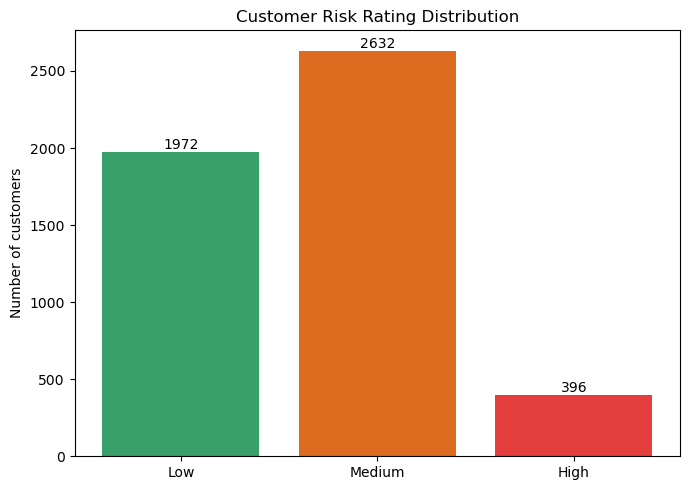

In [19]:
import matplotlib.pyplot as plt

order = ["Low", "Medium", "High"]
colors = {"Low": "#38a169", "Medium": "#dd6b20", "High": "#e53e3e"}
counts = customers["risk_rating"].value_counts().reindex(order)

plt.figure(figsize=(7, 5))
plt.bar(order, counts.values, color=[colors[o] for o in order])
plt.title("Customer Risk Rating Distribution")
plt.ylabel("Number of customers")
for i, v in enumerate(counts.values):
    plt.text(i, v + 20, str(v), ha="center")
plt.tight_layout(); plt.savefig("risk_distribution.png", dpi=150); plt.show()

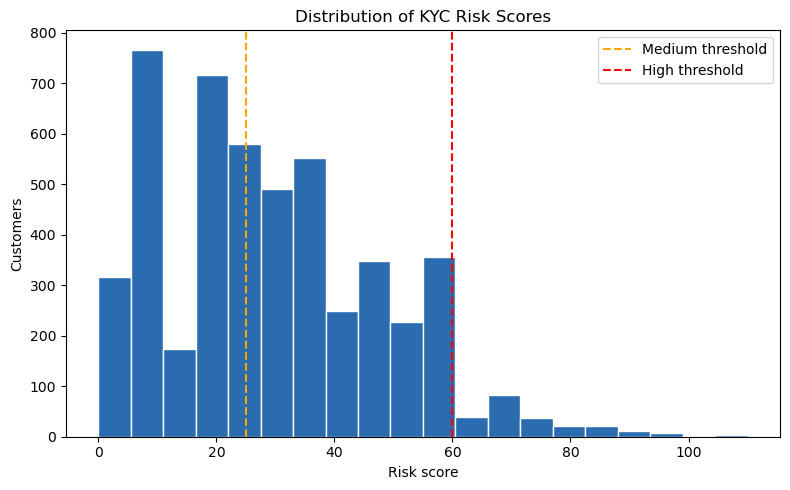

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(customers["risk_score"], bins=20, color="#2b6cb0", edgecolor="white")
plt.axvline(25, color="orange", ls="--", label="Medium threshold")
plt.axvline(60, color="red", ls="--", label="High threshold")
plt.title("Distribution of KYC Risk Scores"); plt.xlabel("Risk score"); plt.ylabel("Customers")
plt.legend(); plt.tight_layout(); plt.savefig("risk_score_hist.png", dpi=150); plt.show()

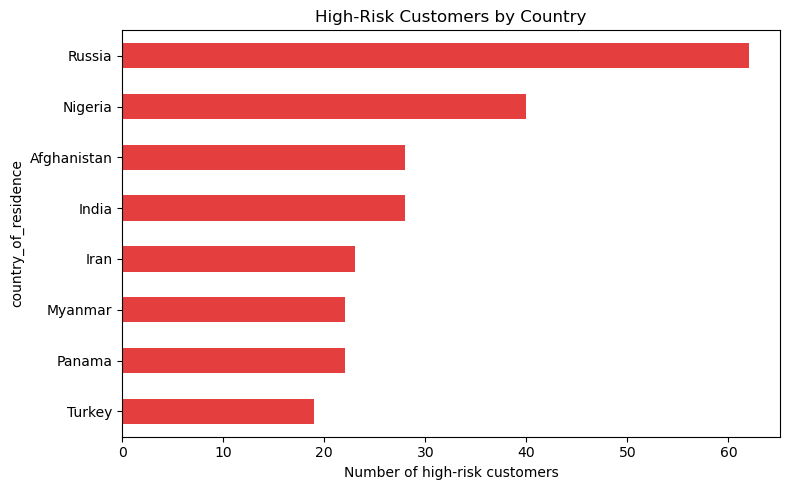

In [21]:
high = customers[customers["risk_rating"] == "High"]["country_of_residence"].value_counts().head(8)

plt.figure(figsize=(8, 5))
high.sort_values().plot(kind="barh", color="#e53e3e")
plt.title("High-Risk Customers by Country"); plt.xlabel("Number of high-risk customers")
plt.tight_layout(); plt.savefig("high_risk_by_country.png", dpi=150); plt.show()

In [22]:
summary = customers[["customer_id","full_name","country_of_residence","occupation",
                     "product_type","is_pep","risk_score","risk_rating",
                     "match_score","activity_ratio"]]
summary.to_csv("kyc_risk_summary.csv", index=False)
print("Saved kyc_risk_summary.csv")

Saved kyc_risk_summary.csv
